<a href="https://colab.research.google.com/github/Teja3993/Deep-Learning-Lab-exercises/blob/main/DL_Lab_experiment_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running Experiment 4: Backpropagation Deep Dive...
Training Network...


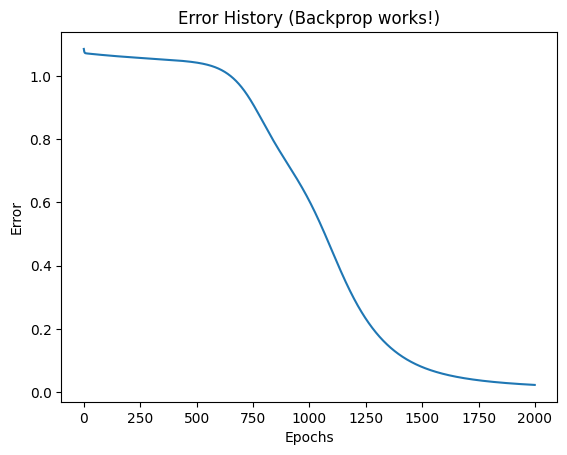

Visualizing what the network learned...


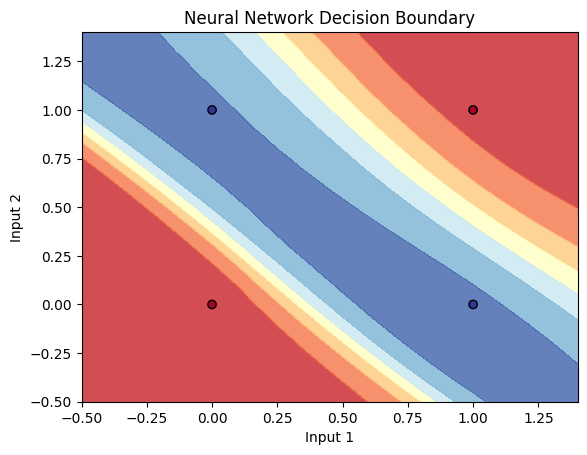


Final Predictions:
Input: [0, 0] -> Predicted: 0.0601 (Expected: 0)
Input: [0, 1] -> Predicted: 0.9217 (Expected: 1)
Input: [1, 0] -> Predicted: 0.9381 (Expected: 1)
Input: [1, 1] -> Predicted: 0.0923 (Expected: 0)


In [1]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np # Needed for the meshgrid/plotting

# ==========================================
# 1. THE STANDARD ANN (Sir's Code - Clean)
# ==========================================
def sigmoid(x):
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    hidden_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

def update_weights(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] += l_rate * neuron['delta']

def train_network(network, train, l_rate, n_epoch):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in train:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

def predict(network, row):
    return forward_propagate(network, row)[0]

# ==========================================
# 2. THE VISUALIZATION DEEP DIVE
# ==========================================
# This function draws the "Mind Map" of the Neural Network
def plot_decision_boundary(network, dataset):
    # Separate data for plotting
    X = np.array([row[:-1] for row in dataset])
    y = np.array([row[-1] for row in dataset])

    # Create a meshgrid (a grid of points covering the whole graph)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predict for every single point on the grid
    Z = []
    for x1, x2 in zip(xx.ravel(), yy.ravel()):
        Z.append(predict(network, [x1, x2]))
    Z = np.array(Z).reshape(xx.shape)

    # Plot contours
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Plot the actual data points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu)
    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.show()

# ==========================================
# 3. EXECUTION
# ==========================================
# Dataset: XOR (Non-Linear Data)
# Format: [Input1, Input2, Expected_Output]
dataset = [
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
]

print("Running Experiment 4: Backpropagation Deep Dive...")

# 1. Initialize
# We need a hidden layer to solve XOR. 2 Inputs -> 4 Hidden -> 1 Output
network = initialize_network(2, 4, 1)

# 2. Train
print("Training Network...")
history = train_network(network, dataset, l_rate=0.5, n_epoch=2000)

# 3. Check Error Graph
plt.plot(history)
plt.title("Error History (Backprop works!)")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

# 4. Show the "Mind Map"
print("Visualizing what the network learned...")
plot_decision_boundary(network, dataset)

# 5. Final Predictions
print("\nFinal Predictions:")
for row in dataset:
    prediction = predict(network, row[:-1])
    print(f"Input: {row[:-1]} -> Predicted: {prediction:.4f} (Expected: {row[-1]})")

Running Experiment 4: Backpropagation Deep Dive...
Training Network...


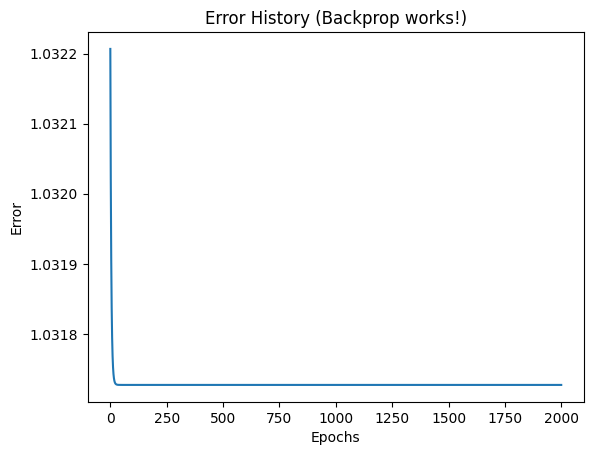

Visualizing what the network learned...


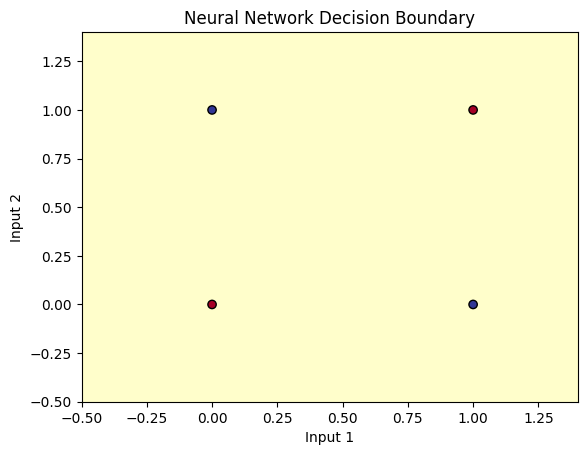


Final Predictions:
Input: [0, 0] -> Predicted: 0.4998 (Expected: 0)
Input: [0, 1] -> Predicted: 0.4998 (Expected: 1)
Input: [1, 0] -> Predicted: 0.4998 (Expected: 1)
Input: [1, 1] -> Predicted: 0.4998 (Expected: 0)


In [2]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np # Needed for the meshgrid/plotting

# ==========================================
# 1. THE STANDARD ANN (Sir's Code - Clean)
# ==========================================
def sigmoid(x):
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    hidden_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

def update_weights(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] += l_rate * neuron['delta']

def train_network(network, train, l_rate, n_epoch):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in train:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

def predict(network, row):
    return forward_propagate(network, row)[0]

# ==========================================
# 2. THE VISUALIZATION DEEP DIVE
# ==========================================
# This function draws the "Mind Map" of the Neural Network
def plot_decision_boundary(network, dataset):
    # Separate data for plotting
    X = np.array([row[:-1] for row in dataset])
    y = np.array([row[-1] for row in dataset])

    # Create a meshgrid (a grid of points covering the whole graph)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predict for every single point on the grid
    Z = []
    for x1, x2 in zip(xx.ravel(), yy.ravel()):
        Z.append(predict(network, [x1, x2]))
    Z = np.array(Z).reshape(xx.shape)

    # Plot contours
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Plot the actual data points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu)
    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.show()

# ==========================================
# 3. EXECUTION
# ==========================================
# Dataset: XOR (Non-Linear Data)
# Format: [Input1, Input2, Expected_Output]
dataset = [
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
]

print("Running Experiment 4: Backpropagation Deep Dive...")

# 1. Initialize
# We need a hidden layer to solve XOR. 2 Inputs -> 4 Hidden -> 1 Output
network = initialize_network(2, 0, 1)

# 2. Train
print("Training Network...")
history = train_network(network, dataset, l_rate=0.5, n_epoch=2000)

# 3. Check Error Graph
plt.plot(history)
plt.title("Error History (Backprop works!)")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

# 4. Show the "Mind Map"
print("Visualizing what the network learned...")
plot_decision_boundary(network, dataset)

# 5. Final Predictions
print("\nFinal Predictions:")
for row in dataset:
    prediction = predict(network, row[:-1])
    print(f"Input: {row[:-1]} -> Predicted: {prediction:.4f} (Expected: {row[-1]})")

Running Experiment 4: Backpropagation Deep Dive...
Training Network...


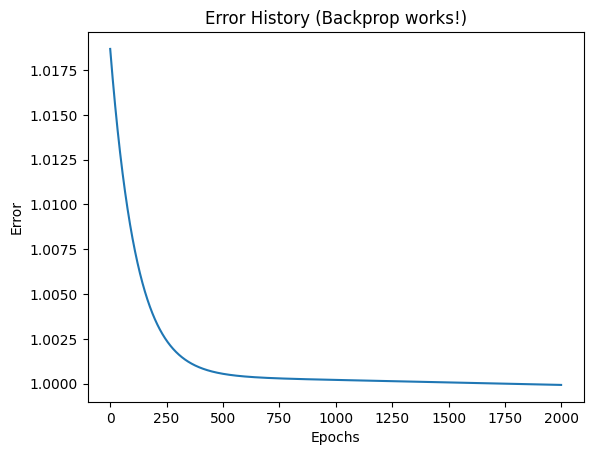

Visualizing what the network learned...


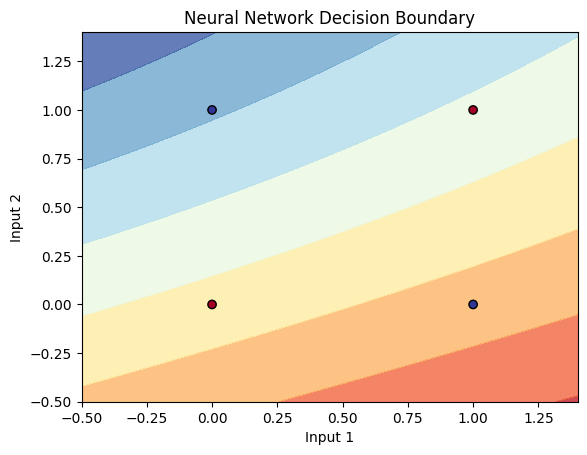


Final Predictions:
Input: [0, 0] -> Predicted: 0.4957 (Expected: 0)
Input: [0, 1] -> Predicted: 0.5108 (Expected: 1)
Input: [1, 0] -> Predicted: 0.4892 (Expected: 1)
Input: [1, 1] -> Predicted: 0.5028 (Expected: 0)


In [3]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np # Needed for the meshgrid/plotting

# ==========================================
# 1. THE STANDARD ANN (Sir's Code - Clean)
# ==========================================
def sigmoid(x):
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    hidden_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])

def update_weights(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] += l_rate * neuron['delta']

def train_network(network, train, l_rate, n_epoch):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in train:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

def predict(network, row):
    return forward_propagate(network, row)[0]

# ==========================================
# 2. THE VISUALIZATION DEEP DIVE
# ==========================================
# This function draws the "Mind Map" of the Neural Network
def plot_decision_boundary(network, dataset):
    # Separate data for plotting
    X = np.array([row[:-1] for row in dataset])
    y = np.array([row[-1] for row in dataset])

    # Create a meshgrid (a grid of points covering the whole graph)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predict for every single point on the grid
    Z = []
    for x1, x2 in zip(xx.ravel(), yy.ravel()):
        Z.append(predict(network, [x1, x2]))
    Z = np.array(Z).reshape(xx.shape)

    # Plot contours
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Plot the actual data points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu)
    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.show()

# ==========================================
# 3. EXECUTION
# ==========================================
# Dataset: XOR (Non-Linear Data)
# Format: [Input1, Input2, Expected_Output]
dataset = [
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
]

print("Running Experiment 4: Backpropagation Deep Dive...")

# 1. Initialize
# We need a hidden layer to solve XOR. 2 Inputs -> 4 Hidden -> 1 Output
network = initialize_network(2, 4, 1)

# 2. Train
print("Training Network...")
history = train_network(network, dataset, l_rate=0.01, n_epoch=2000)

# 3. Check Error Graph
plt.plot(history)
plt.title("Error History (Backprop works!)")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

# 4. Show the "Mind Map"
print("Visualizing what the network learned...")
plot_decision_boundary(network, dataset)

# 5. Final Predictions
print("\nFinal Predictions:")
for row in dataset:
    prediction = predict(network, row[:-1])
    print(f"Input: {row[:-1]} -> Predicted: {prediction:.4f} (Expected: {row[-1]})")

Running Experiment 4: Backpropagation Deep Dive...
Training Network...
Neuron Delta: -0.0101792605309009
Neuron Delta: 0.005972901476066407
Neuron Delta: 0.00717558061561157
Neuron Delta: -0.010780938115315629
Neuron Delta: -0.009140870414016074
Neuron Delta: 0.005759579565758634
Neuron Delta: 0.007007521458876943
Neuron Delta: -0.009978016184234866
Neuron Delta: -0.00831274925839352
Neuron Delta: 0.005533844254893483
Neuron Delta: 0.006825609355658489
Neuron Delta: -0.009329165390457495
Neuron Delta: -0.0076644472688462
Neuron Delta: 0.00532229139441256
Neuron Delta: 0.0066521525115438495
Neuron Delta: -0.008814038085457117
Neuron Delta: -0.007161750237161504
Neuron Delta: 0.005136712970233182
Neuron Delta: 0.0064976803443282044
Neuron Delta: -0.008409249566676573
Neuron Delta: -0.0067736284861828295
Neuron Delta: 0.00498025891543167
Neuron Delta: 0.006365617382764355
Neuron Delta: -0.00809297296011585
Neuron Delta: -0.0064743694062470245
Neuron Delta: 0.0048516569138649926
Neuron Del

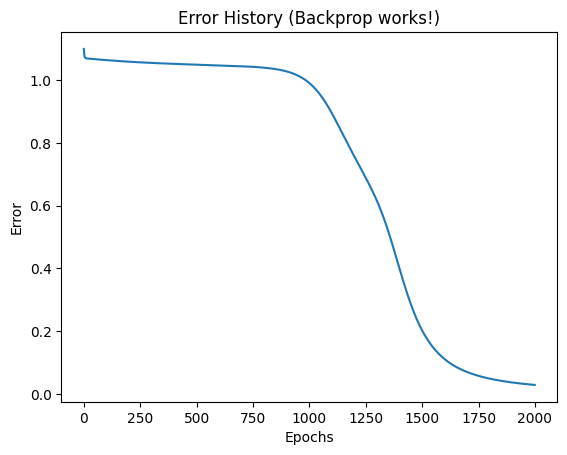

Visualizing what the network learned...


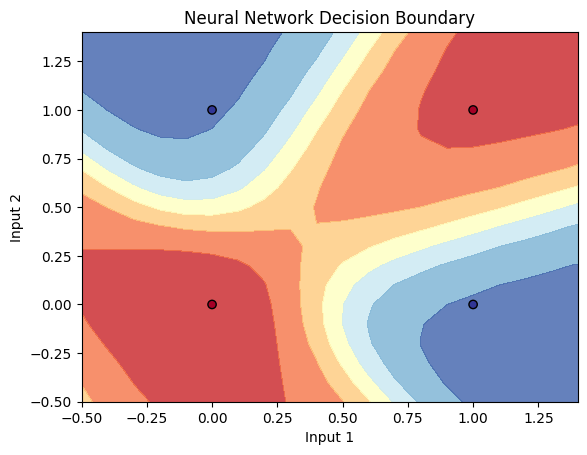


Final Predictions:
Input: [0, 0] -> Predicted: 0.0498 (Expected: 0)
Input: [0, 1] -> Predicted: 0.9198 (Expected: 1)
Input: [1, 0] -> Predicted: 0.9179 (Expected: 1)
Input: [1, 1] -> Predicted: 0.1164 (Expected: 0)


In [4]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np # Needed for the meshgrid/plotting

# ==========================================
# 1. THE STANDARD ANN (Sir's Code - Clean)
# ==========================================
def sigmoid(x):
    if x > 700: x = 700
    if x < -700: x = -700
    return 1.0 / (1.0 + math.exp(-x))

def sigmoid_derivative(output):
    return output * (1.0 - output)

def initialize_network(n_inputs, n_hidden, n_outputs):
    network = []
    hidden_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_inputs + 1)]} for i in range(n_hidden)]
    network.append(hidden_layer)
    output_layer = [{'weights': [random.uniform(-0.5, 0.5) for i in range(n_hidden + 1)]} for i in range(n_outputs)]
    network.append(output_layer)
    return network

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = neuron['weights'][-1] # Bias
            for i in range(len(inputs)):
                activation += neuron['weights'][i] * inputs[i]
            neuron['output'] = sigmoid(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = []
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += (neuron['weights'][j] * neuron['delta'])
                errors.append(error)
        else:
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(expected[j] - neuron['output'])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * sigmoid_derivative(neuron['output'])
    print(f"Neuron Delta: {neuron['delta']}")

def update_weights(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] += l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] += l_rate * neuron['delta']

def train_network(network, train, l_rate, n_epoch):
    history = []
    for epoch in range(n_epoch):
        sum_error = 0
        for row in train:
            forward_propagate(network, row[:-1])
            expected = [row[-1]]
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate)
            sum_error += (expected[0] - network[-1][0]['output'])**2
        history.append(sum_error)
    return history

def predict(network, row):
    return forward_propagate(network, row)[0]

# ==========================================
# 2. THE VISUALIZATION DEEP DIVE
# ==========================================
# This function draws the "Mind Map" of the Neural Network
def plot_decision_boundary(network, dataset):
    # Separate data for plotting
    X = np.array([row[:-1] for row in dataset])
    y = np.array([row[-1] for row in dataset])

    # Create a meshgrid (a grid of points covering the whole graph)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    # Predict for every single point on the grid
    Z = []
    for x1, x2 in zip(xx.ravel(), yy.ravel()):
        Z.append(predict(network, [x1, x2]))
    Z = np.array(Z).reshape(xx.shape)

    # Plot contours
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Plot the actual data points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu)
    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.show()

# ==========================================
# 3. EXECUTION
# ==========================================
# Dataset: XOR (Non-Linear Data)
# Format: [Input1, Input2, Expected_Output]
dataset = [
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
]

print("Running Experiment 4: Backpropagation Deep Dive...")

# 1. Initialize
# We need a hidden layer to solve XOR. 2 Inputs -> 4 Hidden -> 1 Output
network = initialize_network(2, 4, 1)

# 2. Train
print("Training Network...")
history = train_network(network, dataset, l_rate=0.5, n_epoch=2000)

# 3. Check Error Graph
plt.plot(history)
plt.title("Error History (Backprop works!)")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.show()

# 4. Show the "Mind Map"
print("Visualizing what the network learned...")
plot_decision_boundary(network, dataset)

# 5. Final Predictions
print("\nFinal Predictions:")
for row in dataset:
    prediction = predict(network, row[:-1])
    print(f"Input: {row[:-1]} -> Predicted: {prediction:.4f} (Expected: {row[-1]})")